In [1]:
from google.cloud import bigquery

# BigQuery 접속 객체 생성
bq = bigquery.Client(project="ping-v2-503916")

def cost(sql: str) -> float:
    """쿼리를 실행하지 않고 예상 스캔량만 확인한다."""

    cfg = bigquery.QueryJobConfig(
        dry_run=True,
        use_query_cache=False
    )

    job = bq.query(sql, job_config=cfg)
    bytes_processed = job.total_bytes_processed

    mib = bytes_processed / 2**20
    gib = bytes_processed / 2**30
    free_quota_ratio = gib / 1024 * 100

    print(f"예상 스캔량: {mib:,.3f} MiB")
    print(f"예상 스캔량: {gib:,.6f} GiB")
    print(f"월 1 TiB 무료 용량의 약 {free_quota_ratio:.8f}%")

    return gib

In [26]:
# D1, D7, D30
retention_d1_d7_d30_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT 'D1' AS retention_period, 1 AS end_day, 1 AS sort_order
  UNION ALL
  SELECT 'D7', 7, 2
  UNION ALL
  SELECT 'D30', 30, 3
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    -- 탈퇴 기록이 있는 사용자 제외
    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation을 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 다음 날 이후 최초 재접속일
first_login_return AS (
  SELECT
    a.user_id,
    MIN(
      DATE(s.started_at, 'Asia/Seoul')
    ) AS first_login_return_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
  GROUP BY a.user_id
),

-- 첫 투표 세션이 아닌 새로운 세션에서의 최초 재투표일
first_vote_return AS (
  SELECT
    a.user_id,
    MIN(
      DATE(v.voted_at, 'Asia/Seoul')
    ) AS first_vote_return_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id

    -- 첫 투표 당일 행동은 리텐션에서 제외
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date

  GROUP BY a.user_id
)

SELECT
  w.retention_period,

  -- 각 기간을 끝까지 관찰할 수 있었던 사용자
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
  ) AS eligible_user_count,

  -- 접속 리텐션
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
    AND DATE_DIFF(
          l.first_login_return_date,
          a.first_vote_date,
          DAY
        ) BETWEEN 1 AND w.end_day
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
        AND DATE_DIFF(
              l.first_login_return_date,
              a.first_vote_date,
              DAY
            ) BETWEEN 1 AND w.end_day
      ),
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
      )
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  -- 투표 리텐션: 힌트 구매 제외
  COUNTIF(
    a.first_vote_date
      <= DATE_SUB(
           p.data_end_date,
           INTERVAL w.end_day DAY
         )
    AND DATE_DIFF(
          v.first_vote_return_date,
          a.first_vote_date,
          DAY
        ) BETWEEN 1 AND w.end_day
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
        AND DATE_DIFF(
              v.first_vote_return_date,
              a.first_vote_date,
              DAY
            ) BETWEEN 1 AND w.end_day
      ),
      COUNTIF(
        a.first_vote_date
          <= DATE_SUB(
               p.data_end_date,
               INTERVAL w.end_day DAY
             )
      )
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM activated_users AS a
CROSS JOIN params AS p
CROSS JOIN retention_windows AS w
LEFT JOIN first_login_return AS l
  ON a.user_id = l.user_id
LEFT JOIN first_vote_return AS v
  ON a.user_id = v.user_id

GROUP BY
  w.retention_period,
  w.end_day,
  w.sort_order

ORDER BY w.sort_order
"""

In [27]:
cost(retention_d1_d7_d30_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [28]:
df_retention = bq.query(
    retention_d1_d7_d30_sql
).to_dataframe()

display(df_retention)

,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,D1,14843,6725,45.31,6293,42.40
1,D7,14661,8542,58.26,8308,56.67
2,D30,14010,8329,59.45,8120,57.96


In [30]:
# D1 → D7 → D30 순서 정렬
period_order = ["D1", "D7", "D30"]

formatted_df = (
    df_retention
    .set_index("retention_period")
    .reindex(period_order)
    .reset_index()
)

for _, row in formatted_df.iterrows():
    print(f"[{row['retention_period']}]")

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[D1]
관찰 가능 사용자: 14,843명
접속 리텐션: 6,725명 (45.31%)
투표 리텐션: 6,293명 (42.40%)

[D7]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[D30]
관찰 가능 사용자: 14,010명
접속 리텐션: 8,329명 (59.45%)
투표 리텐션: 8,120명 (57.96%)



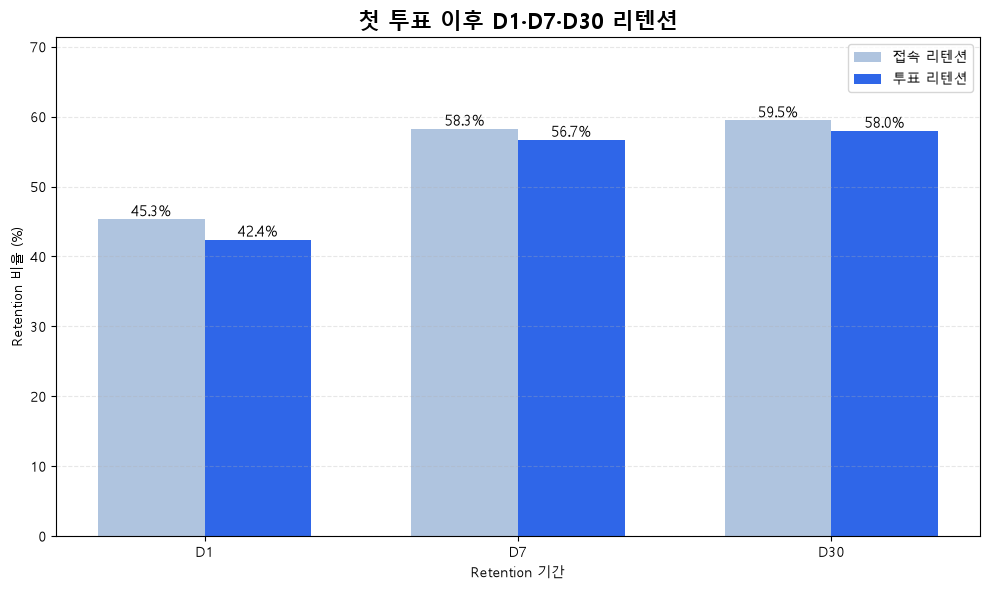

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

periods = df_retention["retention_period"]
login_rates = df_retention["login_retention_rate_percent"]
vote_rates = df_retention["vote_retention_rate_percent"]

x = np.arange(len(periods))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

login_bars = ax.bar(
    x - width / 2,
    login_rates,
    width,
    label="접속 리텐션",
    color="#AFC4DF"
)

vote_bars = ax.bar(
    x + width / 2,
    vote_rates,
    width,
    label="투표 리텐션",
    color="#2F66E8"
)

for bar, value in zip(login_bars, login_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(vote_bars, vote_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 이후 D1·D7·D30 리텐션",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Retention 기간")
ax.set_ylabel("Retention 비율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_ylim(
    0,
    max(login_rates.max(), vote_rates.max()) * 1.2
)

plt.tight_layout()
plt.show()

In [32]:
# W1, W4
retention_w1_w4_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    2
),

-- 탈퇴하지 않은 합성 데이터 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation을 충족한 사용자
activated_users AS (
  SELECT
    u.user_id,
    f.first_vote_at,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 재접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
),

-- 첫 투표 세션 이후 다른 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date
),

-- 각 기간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order
  FROM activated_users AS a
  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,
    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained
  FROM eligible_users AS e
  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id
   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day
  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 투표 리텐션 여부
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,
    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained
  FROM eligible_users AS e
  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id
   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day
  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  COUNT(*) AS eligible_user_count,

  COUNTIF(l.login_retained = 1)
    AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(v.vote_retained = 1)
    AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM eligible_users AS e
JOIN login_flags AS l
  ON e.user_id = l.user_id
 AND e.retention_period = l.retention_period
JOIN vote_flags AS v
  ON e.user_id = v.user_id
 AND e.retention_period = v.retention_period

GROUP BY
  e.retention_period,
  e.sort_order

ORDER BY e.sort_order
"""

In [33]:
cost(retention_w1_w4_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [34]:
df_weekly_retention = bq.query(
    retention_w1_w4_sql
).to_dataframe()

display(df_weekly_retention)

,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,W1,14661,8542,58.26,8308,56.67
1,W4,14057,3011,21.42,2980,21.20


In [35]:
period_order = ["W1", "W4"]

formatted_weekly_df = (
    df_weekly_retention
    .set_index("retention_period")
    .reindex(period_order)
    .reset_index()
)

for _, row in formatted_weekly_df.iterrows():
    print(f"[{row['retention_period']}]")

    print(
        f"관찰 가능 사용자: "
        f"{int(row['eligible_user_count']):,}명"
    )

    print(
        f"접속 리텐션: "
        f"{int(row['login_retained_user_count']):,}명 "
        f"({float(row['login_retention_rate_percent']):.2f}%)"
    )

    print(
        f"투표 리텐션: "
        f"{int(row['vote_retained_user_count']):,}명 "
        f"({float(row['vote_retention_rate_percent']):.2f}%)"
    )

    print()

[W1]
관찰 가능 사용자: 14,661명
접속 리텐션: 8,542명 (58.26%)
투표 리텐션: 8,308명 (56.67%)

[W4]
관찰 가능 사용자: 14,057명
접속 리텐션: 3,011명 (21.42%)
투표 리텐션: 2,980명 (21.20%)



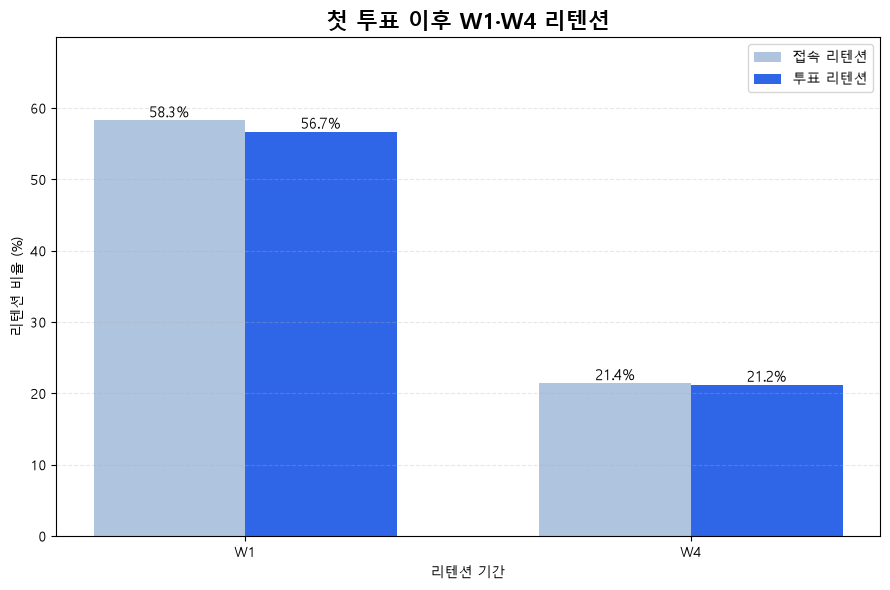

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

periods = df_weekly_retention["retention_period"]
login_rates = df_weekly_retention["login_retention_rate_percent"]
vote_rates = df_weekly_retention["vote_retention_rate_percent"]

x = np.arange(len(periods))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

login_bars = ax.bar(
    x - width / 2,
    login_rates,
    width,
    label="접속 리텐션",
    color="#AFC4DF"
)

vote_bars = ax.bar(
    x + width / 2,
    vote_rates,
    width,
    label="투표 리텐션",
    color="#2F66E8"
)

for bar, value in zip(login_bars, login_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(vote_bars, vote_rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 이후 W1·W4 리텐션",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("리텐션 기간")
ax.set_ylabel("리텐션 비율 (%)")
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

max_rate = max(login_rates.max(), vote_rates.max())
ax.set_ylim(0, max_rate * 1.2)

plt.tight_layout()
plt.show()

In [37]:
# 투표 완료 사용자와 미완료 사용자의 재방문율
completion_revisit_sql = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'W1' AS retention_period,
    1 AS start_day,
    7 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT
    'W4',
    22,
    28,
    2
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.id AS vote_item_id,
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Activation 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 실제 10문항을 완료한 세션
completed_sessions AS (
  SELECT
    vs.user_id,
    vs.id AS session_id
  FROM `ping-v2-503916.raw.vote_session` AS vs
  JOIN actual_votes AS v
    ON v.session_id = vs.id
   AND v.user_id = vs.user_id
  WHERE vs._source = 'local'
    AND vs._deleted_at IS NULL
    AND vs.status = 'COMPLETED'
    AND vs.completed_at IS NOT NULL
    AND vs.item_count = 10
  GROUP BY
    vs.user_id,
    vs.id
  HAVING COUNT(DISTINCT v.vote_item_id) >= 10
),

-- 사용자 단위 완료·미완료 구분
user_segments AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id,

    CASE
      WHEN c.user_id IS NOT NULL THEN '10문항 완료'
      ELSE '10문항 미완료'
    END AS completion_group

  FROM activated_users AS a

  LEFT JOIN (
    SELECT DISTINCT user_id
    FROM completed_sessions
  ) AS c
    ON a.user_id = c.user_id
),

-- 재접속 날짜
login_return_days AS (
  SELECT DISTINCT
    u.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM user_segments AS u
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = u.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > u.first_vote_date
),

-- 다른 투표 세션에서 재투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    u.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM user_segments AS u
  JOIN actual_votes AS v
    ON v.user_id = u.user_id
  WHERE v.session_id != u.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > u.first_vote_date
),

-- 각 구간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    u.user_id,
    u.first_vote_date,
    u.completion_group,
    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order
  FROM user_segments AS u
  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p
  WHERE u.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 접속 재방문 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e
  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id
   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 투표 재방문 여부
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e
  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id
   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
)

SELECT
  e.retention_period,
  e.completion_group,

  COUNT(*) AS eligible_user_count,

  COUNTIF(l.login_retained = 1)
    AS login_return_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(l.login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_return_rate_percent,

  COUNTIF(v.vote_retained = 1)
    AS vote_return_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(v.vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_return_rate_percent

FROM eligible_users AS e
JOIN login_flags AS l
  ON e.user_id = l.user_id
 AND e.retention_period = l.retention_period
JOIN vote_flags AS v
  ON e.user_id = v.user_id
 AND e.retention_period = v.retention_period

GROUP BY
  e.retention_period,
  e.completion_group,
  e.sort_order

ORDER BY
  e.sort_order,
  CASE e.completion_group
    WHEN '10문항 완료' THEN 1
    ELSE 2
  END
"""

In [38]:
cost(completion_revisit_sql)

예상 스캔량: 587.060 MiB
예상 스캔량: 0.573301 GiB
월 1 TiB 무료 용량의 약 0.05598641%


0.5733008729293942

In [39]:
df_completion_revisit = bq.query(
    completion_revisit_sql
).to_dataframe()

display(df_completion_revisit)

,retention_period,completion_group,eligible_user_count,login_return_user_count,login_return_rate_percent,vote_return_user_count,vote_return_rate_percent
0,W1,10문항 완료,10863,7851,72.27,7738,71.23
1,W1,10문항 미완료,3798,691,18.19,570,15.01
2,W4,10문항 완료,10454,3005,28.74,2975,28.46
3,W4,10문항 미완료,3603,6,0.17,5,0.14


In [40]:
period_order = ["W1", "W4"]
group_order = ["10문항 완료", "10문항 미완료"]

formatted_df = df_completion_revisit.copy()

formatted_df["period_order"] = (
    formatted_df["retention_period"]
    .map({period: index for index, period in enumerate(period_order)})
)

formatted_df["group_order"] = (
    formatted_df["completion_group"]
    .map({group: index for index, group in enumerate(group_order)})
)

formatted_df = formatted_df.sort_values(
    ["period_order", "group_order"]
)

for period in period_order:
    print(f"[{period}]")

    period_df = formatted_df[
        formatted_df["retention_period"] == period
    ]

    for _, row in period_df.iterrows():
        print(f"{row['completion_group']} 사용자")

        print(
            f"- 관찰 가능 사용자: "
            f"{int(row['eligible_user_count']):,}명"
        )

        print(
            f"- 접속 재방문: "
            f"{int(row['login_return_user_count']):,}명 "
            f"({float(row['login_return_rate_percent']):.2f}%)"
        )

        print(
            f"- 투표 재방문: "
            f"{int(row['vote_return_user_count']):,}명 "
            f"({float(row['vote_return_rate_percent']):.2f}%)"
        )

        print()

    print()

[W1]
10문항 완료 사용자
- 관찰 가능 사용자: 10,863명
- 접속 재방문: 7,851명 (72.27%)
- 투표 재방문: 7,738명 (71.23%)

10문항 미완료 사용자
- 관찰 가능 사용자: 3,798명
- 접속 재방문: 691명 (18.19%)
- 투표 재방문: 570명 (15.01%)


[W4]
10문항 완료 사용자
- 관찰 가능 사용자: 10,454명
- 접속 재방문: 3,005명 (28.74%)
- 투표 재방문: 2,975명 (28.46%)

10문항 미완료 사용자
- 관찰 가능 사용자: 3,603명
- 접속 재방문: 6명 (0.17%)
- 투표 재방문: 5명 (0.14%)




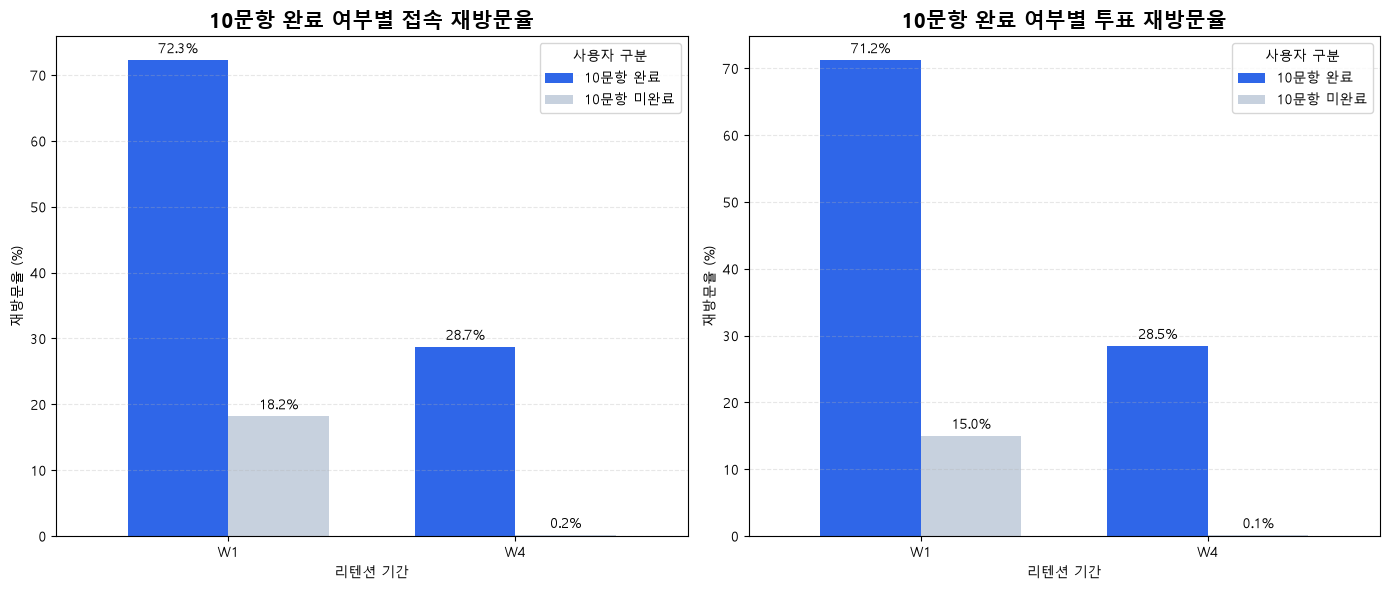

In [41]:
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

period_order = ["W1", "W4"]
group_order = ["10문항 완료", "10문항 미완료"]

login_pivot = (
    df_completion_revisit
    .pivot(
        index="retention_period",
        columns="completion_group",
        values="login_return_rate_percent"
    )
    .reindex(index=period_order, columns=group_order)
)

vote_pivot = (
    df_completion_revisit
    .pivot(
        index="retention_period",
        columns="completion_group",
        values="vote_return_rate_percent"
    )
    .reindex(index=period_order, columns=group_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=["#2F66E8", "#C7D1DE"],
    width=0.7
)

vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=["#2F66E8", "#C7D1DE"],
    width=0.7
)

titles = [
    "10문항 완료 여부별 접속 재방문율",
    "10문항 완료 여부별 투표 재방문율"
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("리텐션 기간")
    ax.set_ylabel("재방문율 (%)")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="사용자 구분")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [42]:
# 사용자당 활동 일수
activity_days_30d_sql = """
WITH params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date,
    30 AS observation_days
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation 충족 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 30일을 전부 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.first_vote_date,
    a.first_vote_session_id
  FROM activated_users AS a
  CROSS JOIN params AS p
  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL p.observation_days DAY
       )
),

-- 사용자별 접속 활동 일수
login_activity AS (
  SELECT
    e.user_id,

    COUNT(
      DISTINCT DATE(s.started_at, 'Asia/Seoul')
    ) AS login_active_days_30d

  FROM eligible_users AS e
  LEFT JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = e.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
   AND s.started_at IS NOT NULL
   AND DATE_DIFF(
         DATE(s.started_at, 'Asia/Seoul'),
         e.first_vote_date,
         DAY
       ) BETWEEN 1 AND 30

  GROUP BY e.user_id
),

-- 사용자별 투표 활동 일수
vote_activity AS (
  SELECT
    e.user_id,

    COUNT(
      DISTINCT DATE(v.voted_at, 'Asia/Seoul')
    ) AS vote_active_days_30d

  FROM eligible_users AS e
  LEFT JOIN actual_votes AS v
    ON v.user_id = e.user_id

    -- 최초 투표 세션의 나머지 투표 제외
   AND v.session_id != e.first_vote_session_id

   AND DATE_DIFF(
         DATE(v.voted_at, 'Asia/Seoul'),
         e.first_vote_date,
         DAY
       ) BETWEEN 1 AND 30

  GROUP BY e.user_id
)

SELECT
  e.user_id,
  e.first_vote_date,

  COALESCE(
    l.login_active_days_30d,
    0
  ) AS login_active_days_30d,

  COALESCE(
    v.vote_active_days_30d,
    0
  ) AS vote_active_days_30d

FROM eligible_users AS e
LEFT JOIN login_activity AS l
  ON e.user_id = l.user_id
LEFT JOIN vote_activity AS v
  ON e.user_id = v.user_id

ORDER BY e.user_id
"""

In [43]:
cost(activity_days_30d_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [44]:
df_activity_days = bq.query(
    activity_days_30d_sql
).to_dataframe()

display(df_activity_days.head())

,user_id,first_vote_date,login_active_days_30d,vote_active_days_30d
0,1,2025-09-03,0,0
1,2,2025-09-01,29,27
2,3,2025-09-01,23,21
3,4,2025-09-01,23,21
4,5,2025-09-04,0,0


In [45]:
import pandas as pd

eligible_user_count = len(df_activity_days)

activity_summary = pd.DataFrame({
    "activity_type": [
        "접속 활동",
        "투표 활동"
    ],
    "average_active_days": [
        df_activity_days["login_active_days_30d"].mean(),
        df_activity_days["vote_active_days_30d"].mean()
    ],
    "median_active_days": [
        df_activity_days["login_active_days_30d"].median(),
        df_activity_days["vote_active_days_30d"].median()
    ],
    "zero_day_user_count": [
        (df_activity_days["login_active_days_30d"] == 0).sum(),
        (df_activity_days["vote_active_days_30d"] == 0).sum()
    ]
})

activity_summary["zero_day_user_rate_percent"] = (
    activity_summary["zero_day_user_count"]
    / eligible_user_count
    * 100
).round(2)

activity_summary["average_active_days"] = (
    activity_summary["average_active_days"].round(2)
)

activity_summary["median_active_days"] = (
    activity_summary["median_active_days"].round(2)
)

display(activity_summary)

,activity_type,average_active_days,median_active_days,zero_day_user_count,zero_day_user_rate_percent
0,접속 활동,6.90,1.0,5681,40.55
1,투표 활동,6.57,1.0,5890,42.04


In [46]:
print(f"30일 관찰 가능 사용자: {eligible_user_count:,}명")
print()

for _, row in activity_summary.iterrows():
    print(f"[{row['activity_type']}]")

    print(
        f"사용자당 평균 활동 일수: "
        f"{row['average_active_days']:.2f}일"
    )

    print(
        f"중앙값: "
        f"{row['median_active_days']:.2f}일"
    )

    print(
        f"활동 0일 사용자: "
        f"{int(row['zero_day_user_count']):,}명 "
        f"({row['zero_day_user_rate_percent']:.2f}%)"
    )

    print()

30일 관찰 가능 사용자: 14,010명

[접속 활동]
사용자당 평균 활동 일수: 6.90일
중앙값: 1.00일
활동 0일 사용자: 5,681명 (40.55%)

[투표 활동]
사용자당 평균 활동 일수: 6.57일
중앙값: 1.00일
활동 0일 사용자: 5,890명 (42.04%)



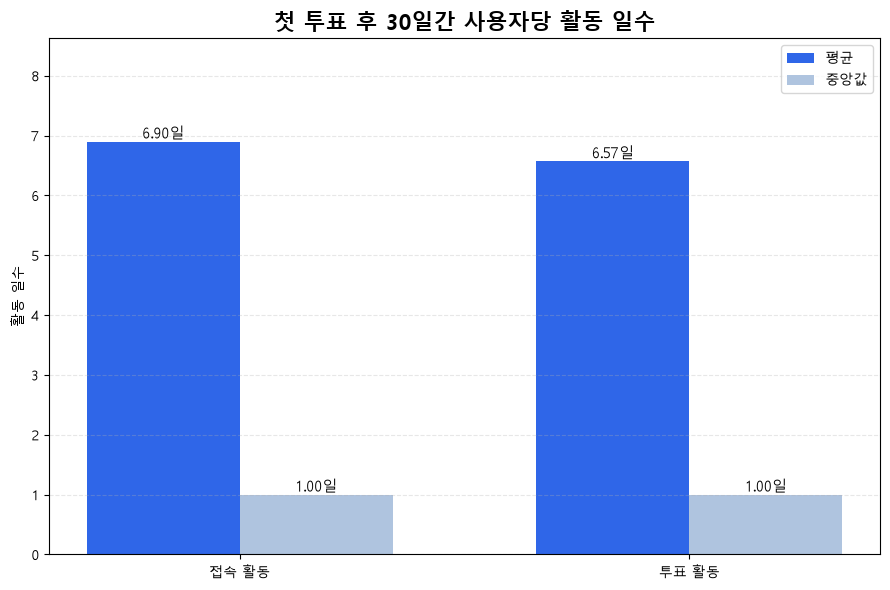

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

labels = activity_summary["activity_type"]
average_days = activity_summary["average_active_days"]
median_days = activity_summary["median_active_days"]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

average_bars = ax.bar(
    x - width / 2,
    average_days,
    width,
    label="평균",
    color="#2F66E8"
)

median_bars = ax.bar(
    x + width / 2,
    median_days,
    width,
    label="중앙값",
    color="#AFC4DF"
)

for bar, value in zip(average_bars, average_days):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}일",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value in zip(median_bars, median_days):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}일",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "첫 투표 후 30일간 사용자당 활동 일수",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("활동 일수")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

max_value = max(average_days.max(), median_days.max())
ax.set_ylim(0, max_value * 1.25 if max_value > 0 else 1)

plt.tight_layout()
plt.show()

In [48]:
# 장기 미접속
long_inactive_return_sql = """
WITH params AS (
  SELECT
    DATE '2026-07-23' AS data_end_date,
    30 AS inactivity_days
),

-- 탈퇴하지 않은 사용자
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at
  FROM `ping-v2-503916.raw.app_user` AS u
  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation 충족 사용자
activated_users AS (
  SELECT
    u.user_id,
    DATE(f.first_vote_at, 'Asia/Seoul') AS first_vote_date,
    f.first_vote_session_id
  FROM valid_users AS u
  JOIN first_vote AS f
    ON u.user_id = f.user_id
  WHERE u.service_unlocked_at IS NOT NULL
),

-- 접속 활동일
access_activity_days AS (
  -- 첫 투표일을 최초 앱 활동일로 설정
  SELECT
    '접속 기준' AS metric_type,
    user_id,
    first_vote_date AS activity_date
  FROM activated_users

  UNION DISTINCT

  SELECT
    '접속 기준' AS metric_type,
    a.user_id,
    DATE(s.started_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL
  WHERE s.started_at IS NOT NULL
    AND DATE(s.started_at, 'Asia/Seoul') > a.first_vote_date
),

-- 투표 활동일
vote_activity_days AS (
  -- 최초 투표일
  SELECT
    '투표 기준' AS metric_type,
    user_id,
    first_vote_date AS activity_date
  FROM activated_users

  UNION DISTINCT

  -- 최초 투표 세션이 아닌 다른 세션의 투표
  SELECT
    '투표 기준' AS metric_type,
    a.user_id,
    DATE(v.voted_at, 'Asia/Seoul') AS activity_date
  FROM activated_users AS a
  JOIN actual_votes AS v
    ON v.user_id = a.user_id
  WHERE v.session_id != a.first_vote_session_id
    AND DATE(v.voted_at, 'Asia/Seoul') > a.first_vote_date
),

all_activity_days AS (
  SELECT * FROM access_activity_days

  UNION ALL

  SELECT * FROM vote_activity_days
),

-- 활동일 다음에 언제 다시 활동했는지 확인
ordered_activity AS (
  SELECT
    metric_type,
    user_id,
    activity_date,

    LEAD(activity_date) OVER (
      PARTITION BY metric_type, user_id
      ORDER BY activity_date
    ) AS next_activity_date

  FROM all_activity_days
),

-- 장기 미활동 및 복귀 여부 판정
episode_flags AS (
  SELECT
    o.metric_type,
    o.user_id,

    -- 장기 미활동 경험 여부
    CASE
      -- 30일 연속 활동하지 않은 후 복귀
      WHEN o.next_activity_date IS NOT NULL
       AND DATE_DIFF(
             o.next_activity_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days + 1
      THEN 1

      -- 데이터 종료일까지 30일 이상 미활동
      WHEN o.next_activity_date IS NULL
       AND DATE_DIFF(
             p.data_end_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days
      THEN 1

      ELSE 0
    END AS has_long_inactive_episode,

    -- 장기 미활동 후 실제 복귀 여부
    CASE
      WHEN o.next_activity_date IS NOT NULL
       AND DATE_DIFF(
             o.next_activity_date,
             o.activity_date,
             DAY
           ) >= p.inactivity_days + 1
      THEN 1
      ELSE 0
    END AS has_returned_episode

  FROM ordered_activity AS o
  CROSS JOIN params AS p
),

-- 사용자 단위 집계
user_summary AS (
  SELECT
    metric_type,
    user_id,

    MAX(
      has_long_inactive_episode
    ) AS is_long_inactive_user,

    MAX(
      has_returned_episode
    ) AS is_returned_user

  FROM episode_flags
  GROUP BY
    metric_type,
    user_id
)

SELECT
  metric_type,

  COUNT(*) AS activated_user_count,

  COUNTIF(
    is_long_inactive_user = 1
  ) AS long_inactive_user_count,

  COUNTIF(
    is_returned_user = 1
  ) AS returned_user_count,

  COUNTIF(
    is_long_inactive_user = 1
  )
  -
  COUNTIF(
    is_returned_user = 1
  ) AS not_returned_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(is_returned_user = 1),
      COUNTIF(is_long_inactive_user = 1)
    ) * 100,
    2
  ) AS return_rate_percent

FROM user_summary
GROUP BY metric_type

ORDER BY
  CASE metric_type
    WHEN '접속 기준' THEN 1
    WHEN '투표 기준' THEN 2
  END
"""

In [49]:
cost(long_inactive_return_sql)

예상 스캔량: 415.822 MiB
예상 스캔량: 0.406076 GiB
월 1 TiB 무료 용량의 약 0.03965591%


0.4060764955356717

In [50]:
df_long_return = bq.query(
    long_inactive_return_sql
).to_dataframe()

display(df_long_return)

,metric_type,activated_user_count,long_inactive_user_count,returned_user_count,not_returned_user_count,return_rate_percent
0,접속 기준,14889,13320,655,12665,4.92
1,투표 기준,14889,13322,656,12666,4.92


In [51]:
metric_order = ["접속 기준", "투표 기준"]

formatted_long_return = (
    df_long_return
    .set_index("metric_type")
    .reindex(metric_order)
    .reset_index()
)

for _, row in formatted_long_return.iterrows():
    print(f"[{row['metric_type']}]")

    print(
        f"장기 미활동 사용자: "
        f"{int(row['long_inactive_user_count']):,}명"
    )

    print(
        f"복귀 사용자: "
        f"{int(row['returned_user_count']):,}명"
    )

    print(
        f"미복귀 사용자: "
        f"{int(row['not_returned_user_count']):,}명"
    )

    print(
        f"복귀율: "
        f"{float(row['return_rate_percent']):.2f}%"
    )

    print()

[접속 기준]
장기 미활동 사용자: 13,320명
복귀 사용자: 655명
미복귀 사용자: 12,665명
복귀율: 4.92%

[투표 기준]
장기 미활동 사용자: 13,322명
복귀 사용자: 656명
미복귀 사용자: 12,666명
복귀율: 4.92%



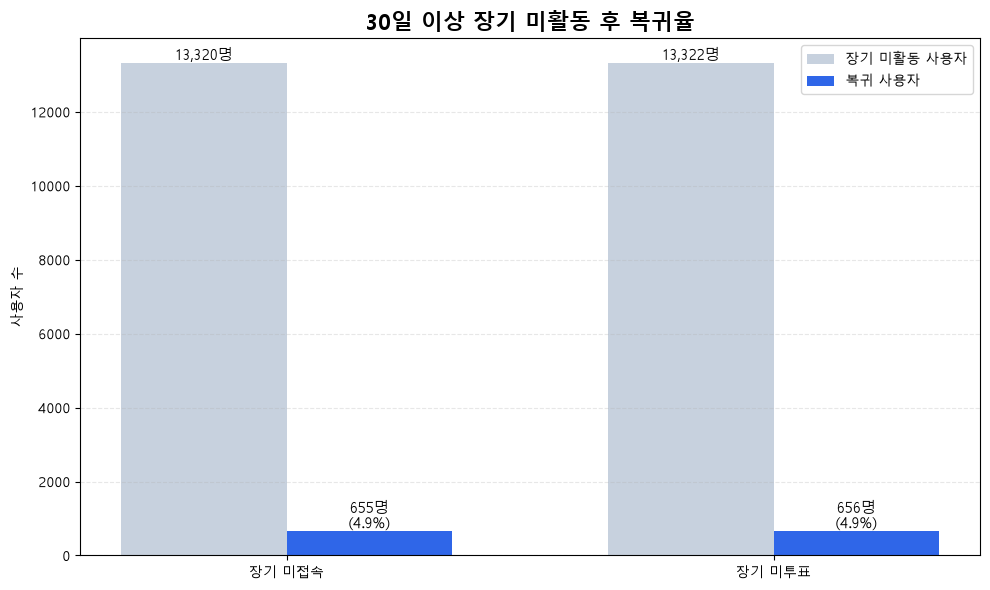

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

labels = df_long_return["metric_type"].replace({
    "접속 기준": "장기 미접속",
    "투표 기준": "장기 미투표"
})

inactive_counts = df_long_return["long_inactive_user_count"]
returned_counts = df_long_return["returned_user_count"]
return_rates = df_long_return["return_rate_percent"]

x = np.arange(len(labels))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 6))

inactive_bars = ax.bar(
    x - width / 2,
    inactive_counts,
    width,
    label="장기 미활동 사용자",
    color="#C7D1DE"
)

returned_bars = ax.bar(
    x + width / 2,
    returned_counts,
    width,
    label="복귀 사용자",
    color="#2F66E8"
)

for bar, value in zip(inactive_bars, inactive_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}명",
        ha="center",
        va="bottom",
        fontsize=11
    )

for bar, value, rate in zip(
    returned_bars,
    returned_counts,
    return_rates
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}명\n({rate:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title(
    "30일 이상 장기 미활동 후 복귀율",
    fontsize=16,
    fontweight="bold"
)
ax.set_ylabel("사용자 수")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 세 쿼리에서 공통으로 사용하는 부분
retention_common_ctes = """
WITH params AS (
  SELECT DATE '2026-07-23' AS data_end_date
),

retention_windows AS (
  SELECT
    'D1' AS retention_period,
    1 AS start_day,
    1 AS end_day,
    1 AS sort_order

  UNION ALL

  SELECT 'D7', 1, 7, 2

  UNION ALL

  SELECT 'D30', 1, 30, 3
),

-- 탈퇴하지 않은 사용자와 학교 정보
valid_users AS (
  SELECT
    u.id AS user_id,
    u.service_unlocked_at,

    s.id AS school_id,
    s.name_masked AS school_name,
    s.school_type,

    gc.grade

  FROM `ping-v2-503916.raw.app_user` AS u

  JOIN `ping-v2-503916.raw.grade_class` AS gc
    ON gc.id = u.class_id
   AND gc._source = 'local'
   AND gc._deleted_at IS NULL

  JOIN `ping-v2-503916.raw.school` AS s
    ON s.id = gc.school_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL

  WHERE u._source = 'local'
    AND u._deleted_at IS NULL

    AND NOT EXISTS (
      SELECT 1
      FROM `ping-v2-503916.raw.user_withdrawal` AS w
      WHERE w._source = 'local'
        AND w._deleted_at IS NULL
        AND w.user_id = u.id
    )
),

-- 실제 투표 기록
actual_votes AS (
  SELECT
    vi.user_id,
    vi.session_id,
    vi.voted_at
  FROM `ping-v2-503916.raw.vote_item` AS vi
  WHERE vi._source = 'local'
    AND vi._deleted_at IS NULL
    AND vi.voted_at IS NOT NULL
),

-- 사용자별 최초 실제 투표
first_vote AS (
  SELECT
    user_id,
    MIN(voted_at) AS first_vote_at,

    ARRAY_AGG(
      session_id
      ORDER BY voted_at
      LIMIT 1
    )[OFFSET(0)] AS first_vote_session_id

  FROM actual_votes
  GROUP BY user_id
),

-- Acquisition과 Activation 충족 사용자
activated_users AS (
  SELECT
    u.user_id,
    u.school_id,
    u.school_name,
    u.school_type,
    u.grade,

    DATE(
      f.first_vote_at,
      'Asia/Seoul'
    ) AS first_vote_date,

    f.first_vote_session_id

  FROM valid_users AS u

  JOIN first_vote AS f
    ON u.user_id = f.user_id

  WHERE u.service_unlocked_at IS NOT NULL
),

-- 첫 투표 이후 다시 접속한 날짜
login_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      s.started_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN `ping-v2-503916.raw.user_session` AS s
    ON s.user_id = a.user_id
   AND s._source = 'local'
   AND s._deleted_at IS NULL

  WHERE s.started_at IS NOT NULL

    AND DATE(
          s.started_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 첫 투표 세션 이후 다른 세션에서 다시 투표한 날짜
vote_return_days AS (
  SELECT DISTINCT
    a.user_id,

    DATE(
      v.voted_at,
      'Asia/Seoul'
    ) AS activity_date

  FROM activated_users AS a

  JOIN actual_votes AS v
    ON v.user_id = a.user_id

  WHERE v.session_id != a.first_vote_session_id

    AND DATE(
          v.voted_at,
          'Asia/Seoul'
        ) > a.first_vote_date
),

-- 각 리텐션 기간을 끝까지 관찰할 수 있는 사용자
eligible_users AS (
  SELECT
    a.user_id,
    a.school_id,
    a.school_name,
    a.school_type,
    a.grade,
    a.first_vote_date,

    w.retention_period,
    w.start_day,
    w.end_day,
    w.sort_order

  FROM activated_users AS a

  CROSS JOIN retention_windows AS w
  CROSS JOIN params AS p

  WHERE a.first_vote_date
    <= DATE_SUB(
         p.data_end_date,
         INTERVAL w.end_day DAY
       )
),

-- 사용자별 접속 리텐션 여부
login_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN l.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS login_retained

  FROM eligible_users AS e

  LEFT JOIN login_return_days AS l
    ON l.user_id = e.user_id

   AND DATE_DIFF(
         l.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 사용자별 투표 리텐션 여부
-- 힌트 구매는 포함하지 않음
vote_flags AS (
  SELECT
    e.user_id,
    e.retention_period,

    MAX(
      CASE
        WHEN v.user_id IS NOT NULL THEN 1
        ELSE 0
      END
    ) AS vote_retained

  FROM eligible_users AS e

  LEFT JOIN vote_return_days AS v
    ON v.user_id = e.user_id

   AND DATE_DIFF(
         v.activity_date,
         e.first_vote_date,
         DAY
       ) BETWEEN e.start_day AND e.end_day

  GROUP BY
    e.user_id,
    e.retention_period
),

-- 최종 사용자 단위 리텐션 데이터
retention_user_flags AS (
  SELECT
    e.user_id,
    e.school_id,
    e.school_name,
    e.school_type,
    e.grade,
    e.retention_period,
    e.sort_order,

    l.login_retained,
    v.vote_retained

  FROM eligible_users AS e

  JOIN login_flags AS l
    ON e.user_id = l.user_id
   AND e.retention_period = l.retention_period

  JOIN vote_flags AS v
    ON e.user_id = v.user_id
   AND e.retention_period = v.retention_period
)
"""

In [69]:
# 학교 유형별 리텐션
school_type_retention_sql = retention_common_ctes + """
SELECT
  CASE
    WHEN school_type = 'M' THEN '중학교'
    WHEN school_type = 'H' THEN '고등학교'
    ELSE school_type
  END AS school_type_name,

  retention_period,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM retention_user_flags

GROUP BY
  school_type,
  retention_period,
  sort_order

ORDER BY
  sort_order,
  school_type_name
"""

In [70]:
cost(school_type_retention_sql)

예상 스캔량: 416.145 MiB
예상 스캔량: 0.406392 GiB
월 1 TiB 무료 용량의 약 0.03968669%


0.40639173332601786

In [71]:
df_school_type_retention = bq.query(
    school_type_retention_sql
).to_dataframe()

display(df_school_type_retention)

,school_type_name,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,HIGH,D1,8487,3903,45.99,3656,43.08
1,MIDDLE,D1,6356,2822,44.40,2637,41.49
2,HIGH,D7,8392,4939,58.85,4801,57.21
3,MIDDLE,D7,6269,3603,57.47,3507,55.94
4,HIGH,D30,8017,4821,60.13,4698,58.60
5,MIDDLE,D30,5993,3508,58.53,3422,57.10


In [72]:
period_order = ["D1", "D7", "D30"]
school_type_order = ["중학교", "고등학교"]

type_output = df_school_type_retention.copy()

type_output["period_order"] = (
    type_output["retention_period"]
    .map({value: index for index, value in enumerate(period_order)})
)

type_output["type_order"] = (
    type_output["school_type_name"]
    .map({value: index for index, value in enumerate(school_type_order)})
)

type_output = type_output.sort_values(
    ["period_order", "type_order"]
)

for period in period_order:
    print(f"[{period}]")

    period_df = type_output[
        type_output["retention_period"] == period
    ]

    for _, row in period_df.iterrows():
        print(f"{row['school_type_name']}")

        print(
            f"- 관찰 가능 사용자: "
            f"{int(row['eligible_user_count']):,}명"
        )

        print(
            f"- 접속 리텐션: "
            f"{int(row['login_retained_user_count']):,}명 "
            f"({float(row['login_retention_rate_percent']):.2f}%)"
        )

        print(
            f"- 투표 리텐션: "
            f"{int(row['vote_retained_user_count']):,}명 "
            f"({float(row['vote_retention_rate_percent']):.2f}%)"
        )

        print()

    print()

[D1]
HIGH
- 관찰 가능 사용자: 8,487명
- 접속 리텐션: 3,903명 (45.99%)
- 투표 리텐션: 3,656명 (43.08%)

MIDDLE
- 관찰 가능 사용자: 6,356명
- 접속 리텐션: 2,822명 (44.40%)
- 투표 리텐션: 2,637명 (41.49%)


[D7]
HIGH
- 관찰 가능 사용자: 8,392명
- 접속 리텐션: 4,939명 (58.85%)
- 투표 리텐션: 4,801명 (57.21%)

MIDDLE
- 관찰 가능 사용자: 6,269명
- 접속 리텐션: 3,603명 (57.47%)
- 투표 리텐션: 3,507명 (55.94%)


[D30]
HIGH
- 관찰 가능 사용자: 8,017명
- 접속 리텐션: 4,821명 (60.13%)
- 투표 리텐션: 4,698명 (58.60%)

MIDDLE
- 관찰 가능 사용자: 5,993명
- 접속 리텐션: 3,508명 (58.53%)
- 투표 리텐션: 3,422명 (57.10%)




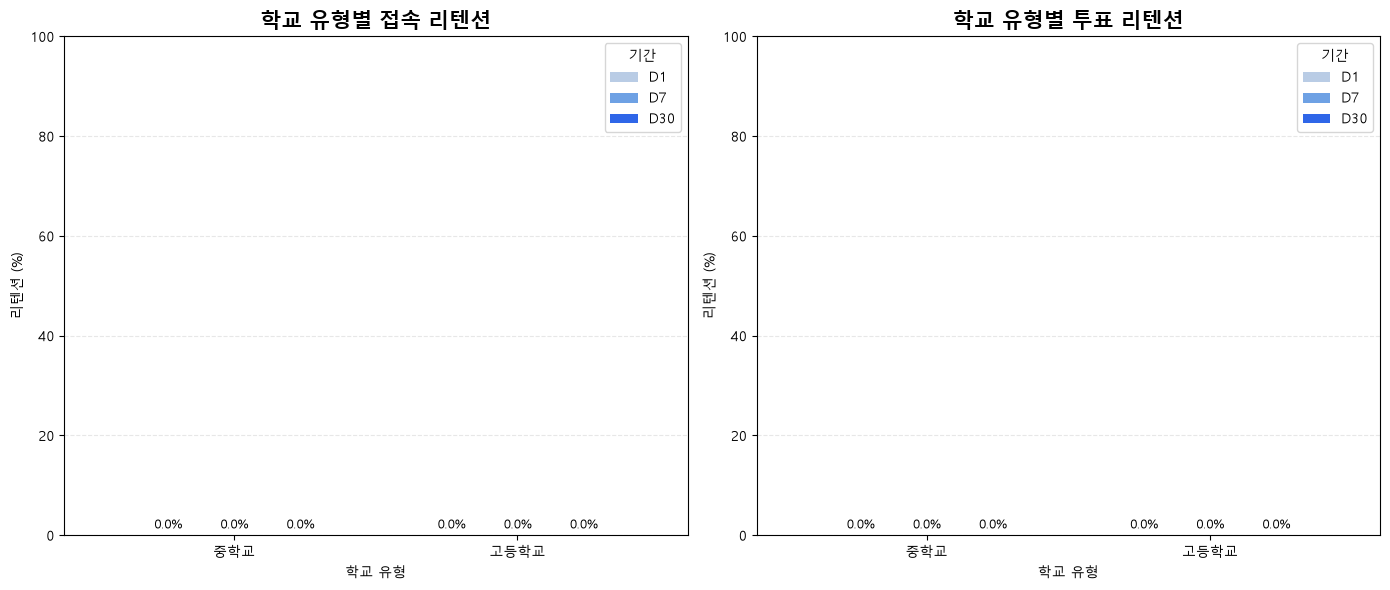

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

period_order = ["D1", "D7", "D30"]
school_type_order = ["중학교", "고등학교"]

login_pivot = (
    df_school_type_retention
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="login_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

vote_pivot = (
    df_school_type_retention
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="vote_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

for ax, title in zip(
    axes,
    ["학교 유형별 접속 리텐션", "학교 유형별 투표 리텐션"]
):
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("학교 유형")
    ax.set_ylabel("리텐션 (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="기간")

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

쿼리에서 변환되지 않은 학교 유형 값과 시각화에서 지정한 중학교·고등학교가 서로 맞지 않아, reindex() 과정에서 값이 전부 결측치가 된 것

In [ ]:
# 1. 실제 학교 유형 값 확인
display(df_school_type_retention)

print(
    df_school_type_retention["school_type_name"]
    .drop_duplicates()
    .tolist()
)

,school_type_name,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,HIGH,D1,8487,3903,45.99,3656,43.08
1,MIDDLE,D1,6356,2822,44.40,2637,41.49
2,HIGH,D7,8392,4939,58.85,4801,57.21
3,MIDDLE,D7,6269,3603,57.47,3507,55.94
4,HIGH,D30,8017,4821,60.13,4698,58.60
5,MIDDLE,D30,5993,3508,58.53,3422,57.10


['HIGH', 'MIDDLE']


In [90]:
# 2. 수정된 학교 유형별 쿼리
school_type_retention_sql = retention_common_ctes + """
SELECT
  CASE
    WHEN school_type = 'M'
      OR UPPER(school_type) LIKE '%MIDDLE%'
    THEN '중학교'

    WHEN school_type = 'H'
      OR UPPER(school_type) LIKE '%HIGH%'
    THEN '고등학교'

    ELSE school_type
  END AS school_type_name,

  retention_period,

  COUNT(*) AS eligible_user_count,

  COUNTIF(
    login_retained = 1
  ) AS login_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(login_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS login_retention_rate_percent,

  COUNTIF(
    vote_retained = 1
  ) AS vote_retained_user_count,

  ROUND(
    SAFE_DIVIDE(
      COUNTIF(vote_retained = 1),
      COUNT(*)
    ) * 100,
    2
  ) AS vote_retention_rate_percent

FROM retention_user_flags

GROUP BY
  school_type,
  retention_period,
  sort_order

ORDER BY
  sort_order,
  school_type_name
"""

In [91]:
cost(school_type_retention_sql)

예상 스캔량: 416.145 MiB
예상 스캔량: 0.406392 GiB
월 1 TiB 무료 용량의 약 0.03968669%


0.40639173332601786

In [92]:
df_school_type_retention = bq.query(
    school_type_retention_sql
).to_dataframe()

display(df_school_type_retention)

,school_type_name,retention_period,eligible_user_count,login_retained_user_count,login_retention_rate_percent,vote_retained_user_count,vote_retention_rate_percent
0,고등학교,D1,8487,3903,45.99,3656,43.08
1,중학교,D1,6356,2822,44.40,2637,41.49
2,고등학교,D7,8392,4939,58.85,4801,57.21
3,중학교,D7,6269,3603,57.47,3507,55.94
4,고등학교,D30,8017,4821,60.13,4698,58.60
5,중학교,D30,5993,3508,58.53,3422,57.10


[접속 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_type_name,,,
중학교,44.40,57.47,58.53
고등학교,45.99,58.85,60.13


[투표 리텐션 시각화 데이터]


retention_period,D1,D7,D30
school_type_name,,,
중학교,41.49,55.94,57.1
고등학교,43.08,57.21,58.6


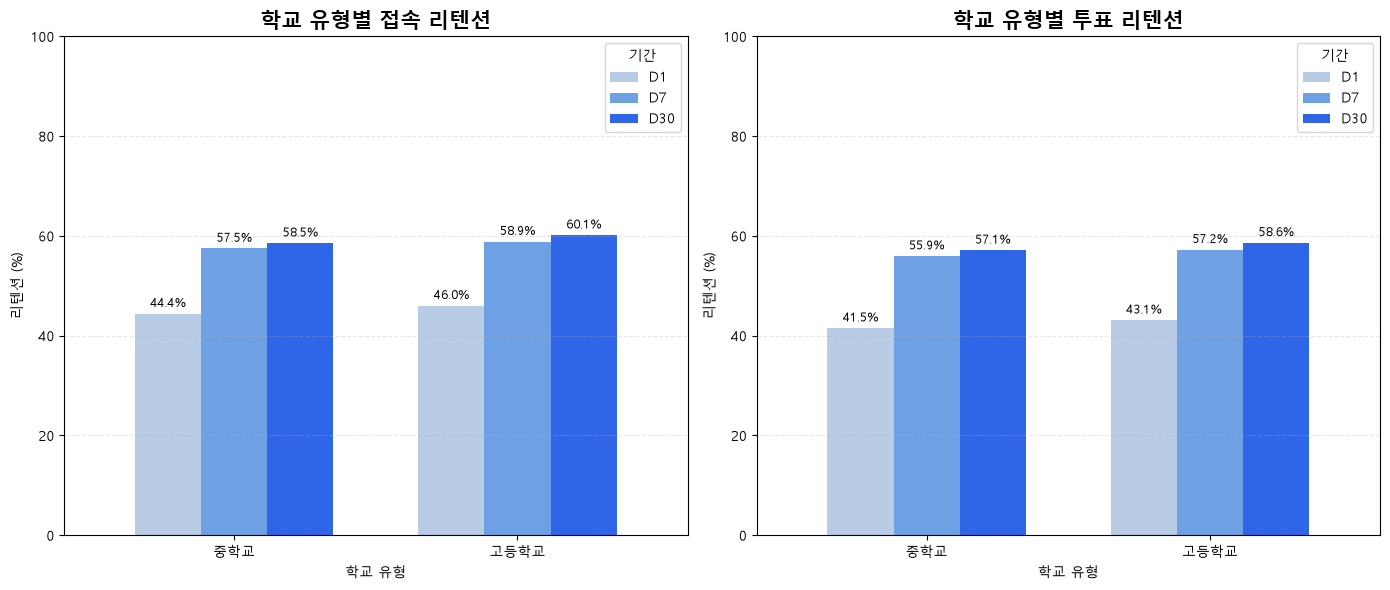

In [93]:
# 3. 수정한 시각화
import pandas as pd
import matplotlib.pyplot as plt
import platform

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"

plt.rcParams["axes.unicode_minus"] = False

plot_df = df_school_type_retention.copy()

# 리텐션 컬럼을 확실하게 숫자형으로 변환
rate_columns = [
    "login_retention_rate_percent",
    "vote_retention_rate_percent"
]

for column in rate_columns:
    plot_df[column] = pd.to_numeric(
        plot_df[column],
        errors="coerce"
    )

period_order = ["D1", "D7", "D30"]
school_type_order = ["중학교", "고등학교"]

login_pivot = (
    plot_df
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="login_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

vote_pivot = (
    plot_df
    .pivot(
        index="school_type_name",
        columns="retention_period",
        values="vote_retention_rate_percent"
    )
    .reindex(
        index=school_type_order,
        columns=period_order
    )
)

print("[접속 리텐션 시각화 데이터]")
display(login_pivot)

print("[투표 리텐션 시각화 데이터]")
display(vote_pivot)

# 데이터가 모두 비어 있으면 그래프를 그리지 않고 오류 표시
if login_pivot.isna().all().all():
    raise ValueError(
        "접속 리텐션 데이터가 모두 비어 있습니다. "
        "school_type_name 값을 확인해주세요."
    )

if vote_pivot.isna().all().all():
    raise ValueError(
        "투표 리텐션 데이터가 모두 비어 있습니다. "
        "school_type_name 값을 확인해주세요."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

login_pivot.plot(
    kind="bar",
    ax=axes[0],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

vote_pivot.plot(
    kind="bar",
    ax=axes[1],
    color=["#B9CCE5", "#6EA1E4", "#2F66E8"],
    width=0.7
)

for ax, title in zip(
    axes,
    [
        "학교 유형별 접속 리텐션",
        "학교 유형별 투표 리텐션"
    ]
):
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold"
    )
    ax.set_xlabel("학교 유형")
    ax.set_ylabel("리텐션 (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(title="기간")

    for container in ax.containers:
        labels = [
            f"{bar.get_height():.1f}%"
            if pd.notna(bar.get_height())
            else ""
            for bar in container
        ]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()